### 第 05 章 深度 Q 网络（DQN）


#### 本章概述

本章将介绍强化学习领域的一个重要里程碑——**深度 Q 网络（Deep Q-Network, DQN）**。DQN 是由 DeepMind 提出的一种将深度学习与强化学习成功结合的算法，在 Atari 游戏中达到了人类水平的表现。它成功克服了上一章提到的“致命三要素”带来的训练不稳定问题。

**学习目标**：
- 理解从 Q-Learning 到 DQN 的演进动机。
- 掌握 DQN 赖以成功的两大核心技术：经验回放（Experience Replay）与目标网络（Target Network）。
- 了解 DQN 的主流改进算法（Double DQN, Dueling DQN 等）。
- 学习 DQN 的实现细节和工程调试技巧。

**前置知识**：
- 需要掌握 Q-Learning 算法的更新公式。
- 掌握上一章中关于函数近似和神经网络在强化学习中应用的挑战。


##### 5.1 从 Q-Learning 到 DQN


**理论部分**

传统的 **Q-Learning** 是一种基于表格的方法。它通过维护一个 $Q$-table 来记录每一个状态-动作对 $(s, a)$ 的价值，其更新公式为：
$$ Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_a Q(S_{t+1}, a) - Q(S_t, A_t) \right] $$

正如我们在第 4 章所讨论的，面对高维状态（如像素图像输入），表格型 Q-Learning 会遭遇**维度灾难**，且无法实现**泛化**。为此，我们引入了非线性函数近似——深度神经网络。

**DQN（Deep Q-Network）** 本质上就是**带有神经网络的 Q-Learning**。它使用一个参数为 $\theta$ 的神经网络 $Q(s, a; \theta)$ 来近似真实的 $Q$ 值。

按照 Q-Learning 的逻辑，其目标损失函数应该为均方误差：
$$ J(\theta) = \mathbb{E}_{(s, a, r, s')} \left[ \left( r + \gamma \max_{a'} Q(s', a'; \theta) - Q(s, a; \theta) \right)^2 \right] $$

然而，直接像上述这样用神经网络去拟合，往往会导致发散和训练崩溃。原因正是因为上一章提到的**致命三要素**：
1. **非静态目标**：我们用同一个网络来计算预测值 $Q(s, a; \theta)$ 和目标值 $r + \gamma \max_{a'} Q(s', a'; \theta)$。网络每次更新，目标也在跟着不断移动（狗咬尾巴问题）。
2. **样本相关性**：智能体在环境中的连续交互样本（状态序列）存在极强的时序相关性，打破了神经网络优化所需的独立同分布（i.i.d）假设。

为了解决这些问题，DQN 引入了以下将要介绍的两大核心技术。

**关键要点**：
- DQN 是深度学习与 Q-Learning 的结合。
- 简单地用神经网络替换 Q-table 无法工作，因为面临非静态目标和数据相关性导致的不稳定。


In [1]:
import numpy as np 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import random 
 
# 我们首先定义 DQN 中的神经网络结构 
# 这是一个简单的多层感知机 (MLP) 示例，用于处理一维向量输入（如环境的状态特征） 
class QNetwork(nn.Module): 
    def __init__(self, state_dim, action_dim, hidden_dim=64): 
        # 调用父类的初始化方法 
        super(QNetwork, self).__init__() 
         
        # 定义第一层全连接层：输入维度为状态维度 state_dim，输出维度为隐藏层维度 hidden_dim 
        self.fc1 = nn.Linear(state_dim, hidden_dim) 
         
        # 定义第二层全连接层：输入和输出维度均为 hidden_dim，用于进一步提取特征 
        self.fc2 = nn.Linear(hidden_dim, hidden_dim) 
         
        # 定义输出层（第三层全连接层）：输入维度为 hidden_dim，输出维度为动作维度 action_dim 
        # 这一层的输出直接对应着每个动作的 Q 值评估 
        self.fc3 = nn.Linear(hidden_dim, action_dim) 
         
    def forward(self, x): 
        # 前向传播过程 
        # 输入状态 x，首先通过第一层全连接层，并应用 ReLU 激活函数引入非线性 
        x = F.relu(self.fc1(x)) 
         
        # 将上一层的输出传入第二层全连接层，同样应用 ReLU 激活函数 
        x = F.relu(self.fc2(x)) 
         
        # 最后通过输出层，这里不需要激活函数，因为输出的是连续的 Q 值（表示预期的累积奖励） 
        # 返回该状态下所有可选动作的 Q 值向量 
        return self.fc3(x)

##### 5.2 DQN 的核心技术


**理论部分**

**1. 经验回放（Experience Replay）**

经验回放的思路非常直接：我们不再使用智能体刚刚产生的连续转移来立刻更新网络。相反，我们将智能体与环境交互产生的数据元组 $e_t = (S_t, A_t, R_{t+1}, S_{t+1}, \text{done})$ 存储在一个大容量的**回放缓冲区（Replay Buffer）** $\mathcal{D}$ 中。

在训练时，我们从缓冲区中**随机采样（Random Sampling）**一个小批量（Mini-batch）的数据来更新网络参数。

**优点**：
- **打破相关性**：随机采样打乱了数据的时序顺序，极大降低了样本间的相关性，使得数据更符合 i.i.d 假设。
- **数据复用**：过去的经验可以被多次采样学习，提高了数据利用率。
- **平滑分布**：有助于稳定数据的分布，避免网络过拟合到当前这一小段轨迹。

**2. 目标网络（Target Network）**

为了解决目标不断移动带来的不稳定，DQN 引入了第二个网络：**目标网络 $\hat{Q}$**。它的结构与主网络 $Q$ 完全相同，参数分别为 $\theta^-$ 和 $\theta$。

- **主网络 $Q(s, a; \theta)$**：频繁更新。用于选择动作和评估当前 Q 值。
- **目标网络 $\hat{Q}(s, a; \theta^-)$**：参数被冻结，只在每隔 $C$ 步之后，才将主网络的参数复制给它（$\theta^- \leftarrow \theta$），或者采用软更新策略。

引入目标网络后，损失函数变为：
$$ J(\theta) = \mathbb{E}_{(s, a, r, s') \sim \mathcal{D}} \left[ \left( r + \gamma \max_{a'} \hat{Q}(s', a'; \theta^-) - Q(s, a; \theta) \right)^2 \right] $$
在这个公式中，目标项（含 $\hat{Q}$）因为参数冻结，在一段时间内变成了固定的标签，从而将强化学习在短期内转换为一个较为稳定的监督学习回归问题。

**关键要点**：
- **经验回放**：解决数据相关性，提高样本利用率。
- **目标网络**：提供静态的自举目标，稳定训练过程。


In [2]:
from collections import deque 
import numpy as np 
import random 
 
# 实现一个简单的经验回放缓冲区 (Replay Buffer) 
# 作用是存储智能体的交互经验，打破数据的时间相关性，使其符合独立同分布假设 
class ReplayBuffer: 
    def __init__(self, capacity): 
        # 使用 collections.deque 维持一个固定容量的双端队列 
        # maxlen=capacity 保证了当队列满时，新加入的元素会自动挤出（剔除）最旧的数据 
        self.buffer = deque(maxlen=capacity) 
         
    def push(self, state, action, reward, next_state, done): 
        # 将单条经验元组 (s, a, r, s', done) 存入缓冲区 
        self.buffer.append((state, action, reward, next_state, done)) 
         
    def sample(self, batch_size): 
        # 随机采样一个批次 (batch_size) 的数据用于训练 
        # random.sample 可以无放回地从 buffer 中随机抽取指定数量的元素 
        # zip(*...) 是将列表中包含元组的数据进行解包，把相同位置的元素打包在一起 
        state, action, reward, next_state, done = zip(*random.sample(self.buffer, batch_size)) 
         
        # 将解包后的元组分别转换为 Numpy 数组，方便后续统一转换为 PyTorch Tensor 参与计算 
        # done 信号通常用作掩码（0表示未结束，1表示结束），因此转换为 uint8 或布尔类型 
        return (np.array(state), np.array(action), np.array(reward, dtype=np.float32),  
                np.array(next_state), np.array(done, dtype=np.uint8)) 
     
    def __len__(self): 
        # 返回当前缓冲区中已经存储的经验数量 
        return len(self.buffer) 
 
# ----------------- 目标网络演示部分 ----------------- 
# 演示目标网络 (Target Network) 的用法（伪代码逻辑片段） 
state_dim = 4    # 假设环境状态为 4 维特征向量 
action_dim = 2   # 假设有 2 个离散的可选动作 
 
# 1. 初始化主网络 (q_net) 和目标网络 (target_net) 
q_net = QNetwork(state_dim, action_dim) 
target_net = QNetwork(state_dim, action_dim) 
 
# 2. 将主网络的初始参数完完全全复制给目标网络，确保二者起点一致 
target_net.load_state_dict(q_net.state_dict()) 
 
# 3. 目标网络的参数在训练过程中是不通过反向传播计算梯度的（只做推断/评估） 
# 因此将其 requires_grad 属性设为 False，既能节省内存也能避免误更新 
for param in target_net.parameters(): 
    param.requires_grad = False 
 
# 4. 定义参数同步函数（在训练时，每隔 C 步调用一次该函数，即硬更新 Hard Update） 
def sync_target_network(): 
    # 再次把主网络学习到的最新参数覆盖到目标网络中 
    target_net.load_state_dict(q_net.state_dict())

##### 5.3 DQN 的改进算法


**理论部分**

基础的 DQN 仍存在一些缺陷，后续研究者提出了许多经典的改进变体。这些改进变体经常被组合使用。

**1. Double DQN (DDQN)**
- **问题**：标准 DQN 的目标计算中包含了 $\max_{a'} \hat{Q}(s', a'; \theta^-)$。由于使用同一个网络（或同样参数的旧网络）来同时**选择动作**和**评估该动作的价值**，往往会导致 Q 值被严重高估（Overestimation）。
>在标准的 DQN 中，我们用来更新神经网络参数 $\theta$ 的 TD 目标（TD Target）公式如下：
>$$\boxed{Y^\text{DQN}_t = r_{t+1} + \gamma \max_{a'} \hat{Q}(s', a')}$$
>这里的 $\max_{a'}$ 操作。DQN使用同一个目标网络 $\theta^-$ 来同时完成两件事：
>选择动作（找出那个让 Q 值最大的动作）。
>评估价值（用找到的最大 Q 值作为未来的期望收益）。
>
>DQN的TD target可以写作：$Y^\text{DQN}_t = r_{t+1} + \gamma \max_{a'} \hat{Q}(s', a) = r_{t+1} + Q(s',  \text{arg max}_a' \hat{Q}(s',a'))$. 换句话说，操作实际可以被拆解为两部分：首先选取状态下的最优动作: $a'^{*}= \text{arg max}_{a'}Q_{\theta^-}(s',a')$，接着计算该动作对应的价值 $\hat{Q}(s', a'^*)$。 当这两部分采用同一套 $\hat{Q}$(目标网络)网络进行计算时，每次得到的都是神经网络当前估算的所有动作价值中的最大值。考虑到通过神经网络估算的值本身在某些时候会产生正向或负向的误差，在 DQN 的更新方式下神经网络会将正向误差累积。
>
>例如，我们考虑一个特殊情形：在状态 $s'$ 下所有动作的值 $Q$ 均为 0，即$Q(s',a'_i) = 0, \forall i$，此时正确的更新目标应为$r_{t+1} + 0$，但是由于神经网络拟合的误差通常会出现某些动作的估算有正误差的情况，即存在某个动作$a'$有 $Q(s',a') > 0$，此时我们的更新目标出现了过高估计，$r_{t+1} + \gamma \max_{a'} Q(s',a') > r_{t+1} + 0$。因此，当我们用 DQN 的更新公式进行更新时，$Q(s,a)$也就会被过高估计了。同理，我们拿这个$Q(s,a)$来作为更新目标来更新上一步的值时，同样会过高估计，这样的误差将会逐步累积。对于动作空间较大的任务，DQN 中的过高估计问题会非常严重，造成 DQN 无法有效工作的后果。

- **改进**：解耦动作的选择与价值的评估。使用当前的主网络 $Q$ 来选择未来状态 $s'$ 的最佳动作，用目标网络 $\hat{Q}$ 来评估这个动作的价值。
- **目标公式**：
  $$\boxed{Y^{\text{DDQN}}_t = r_{t+1} + \gamma \underbrace{\hat{Q} \left( s', \underbrace{\color{blue}{\text{arg max}_{a'} Q(s',a')}}_{\text{通过策略网络选择动作}}\right)}_{\text{通过目标网络评估动作}}}$$
**2. Dueling DQN**

Double DQN (DDQN) 是对算法目标公式的改良（解决了过估计问题）。那么 Dueling DQN 则是对神经网络架构的革命性改造。它在传统 DQN 的基础上只进行了微小的改动，但却能大幅提升 DQN 的表现。

在传统的 DQN 中，神经网络接收一个状态 $s$，经过一系列隐藏层后，直接输出该状态下所有可选动作的 Q 值：$Q(s, a_1), Q(s, a_2), \dots$。

>Dueling DQN 的核心思想在于：一个动作的 $Q(s, a)$ 值，实际上是由两部分叠加而成的：
>- **状态本身的价值 $V(s)$**：仅仅是处于当前状态 $s$ 有多好，与你接下来采取什么动作无关。
>- **动作的优势 $A(s, a)$**：在当前状态 $s$ 下，采取动作 $a$ 相比于采取该状态下的“平均”动作，能给你带来多少额外的好处。

>Dueling DQN 将神经网络在输出端分流成了两个独立的分支：
>- **分支 1（Value Stream）**：专门输出一个标量 $V(s)$。
>- **分支 2（Advantage Stream）**：输出一个向量，代表每个动作的优势值 $A(s, a)$。
>- **聚合层（Aggregation Layer）**：在网络的最后，将这两个分支的结果重新相加，组合成最终的 $Q(s, a)$。

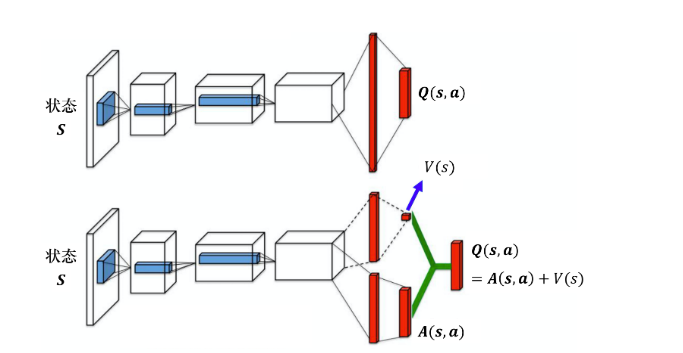

**有什么好处呢？**
将状态价值函数和优势函数分别建模的好处在于：某些情境下智能体只会关注状态的价值，而并不关心不同动作导致的差异，此时将二者分开建模能够使智能体更好地处理与动作关联较小的状态。

从直觉上，我们很容易写出聚合层的公式：
$$Q(s, a) = V(s) + A(s, a)$$

但在实际用神经网络逼近这个公式时，我们会遇到一个致命的数学问题——**不可辨识性（Unidentifiability）**。

**什么是不可辨识性？**
假设神经网络共享层的参数为 $\theta$，价值分支的参数为 $\beta$，优势分支的参数为 $\alpha$。如果直接让网络输出：
$$Q(s, a; \theta, \alpha, \beta) = V(s; \theta, \beta) + A(s, a; \theta, \alpha)$$
给定一个真实的 $Q$ 值，网络是无法唯一确定 $V$ 和 $A$ 的分别贡献的。

**数学证明**：假设对 $V$ 加上一个任意常数 $C$，同时对所有的 $A$ 减去同一个常数 $C$：
$$Q = (V + C) + (A - C) = V + A$$
最终得到的 $Q$ 值完全没变！这会导致在反向传播更新梯度时，$V$ 和 $A$ 会互相推诿、剧烈波动，根本无法学到各自真实的物理意义（$V$ 学不到真正的状态价值，$A$ 也学不到真正的动作优势）。

为了打破这种无意义的自由度，我们需要强行加一个数学约束。Dueling DQN 的作者提出了两种约束方案，在聚合层强制对 $A(s, a)$ 进行**居中处理（Centering）**。

**方案 A（强制最优动作的优势为 0）**：
$$Q(s, a; \theta, \alpha, \beta) = V(s; \theta, \beta) + \left( A(s, a; \theta, \alpha) - \max_{a'} A(s, a'; \theta, \alpha) \right)$$
此时，如果我们去求 $\max_a Q(s,a)$，由于括号里最大的一项必然等于 $0$，我们会得到 $\max_a Q(s,a) = V(s)$。这在数学上完美契合了 $V(s)$ 的定义（最优策略下，状态价值等于最大动作价值）。

**方案 B（强制所有动作的平均优势为 0）—— 实际工程中最常用的版本**：
$$Q(s, a; \theta, \alpha, \beta) = V(s; \theta, \beta) + \left( A(s, a; \theta, \alpha) - \frac{1}{|\mathcal{A}|} \sum_{a'} A(s, a'; \theta, \alpha) \right)$$
在这个版本中，所有的优势值被强制减去了它们的均值。这保证了 $\sum_a A(s, a) = 0$。
虽然它在理论上不如方案 A 那么贴合 $V(s)$ 的严谨定义，但在神经网络的实际优化中，减去均值（方案 B）极大地提高了训练的稳定性。因为均值操作对单个动作优势值的剧烈变化不那么敏感，梯度传播更加平滑。

通过这种强制居中，给定的 $Q$ 值就能被唯一地拆解为 $V$ 和 $A$，不可辨识性危机解除！

**为什么 Dueling 架构更强？**
部分原因在于 Dueling DQN 能更高效学习状态价值函数。每一次更新时，函数 $V$ 都会被更新，这也会影响到其他动作的值 $Q$。而传统的 DQN 只会更新某个动作的值 $Q$，其他动作的值 $Q$ 就不会更新。因此，Dueling DQN 能够更加频繁、准确地学习状态价值函数。

**在高速公路上开车：**
- **状态 $s_1$（前方一路畅通）**：此时你的状态价值 $V(s_1)$ 非常高。无论你采取什么动作（踩油门、微微左转、微微右转），只要不撞护栏，其实结果都差不多好。
- **状态 $s_2$（前方有一辆大卡车急刹车）**：此时你的状态价值 $V(s_2)$ 极低（极度危险）。你的动作优势 $A(s, a)$ 变得至关重要：猛打方向盘变道的优势极高，而继续踩油门的优势极低。

**传统 DQN 的困境**：
在状态 $s_1$（一路畅通）下，假设有 10 个可用的微调动作。传统 DQN 必须对这 10 个动作的 $Q$ 值进行 10 次独立的训练，才能让这 10 个动作的预测值都达到很高。这极其浪费采样效率。

**Dueling DQN 的降维打击**：
在同样的 $s_1$ 下，Dueling DQN 的网络一看到路况好，$V(s)$ 分支立刻就输出了一个很高的分数。而对于那 10 个动作的优势值 $A(s,a)$ 分支，它只要输出几乎全是 0（或者非常小的值）就可以了。
这意味着，哪怕有些动作你根本没尝试过，只要网络认出了这是一个“好状态”，它就能通过 $V(s)$ 直接赋予所有未探索动作一个不错的基础估值。

因此，环境中存在大量“动作选择对结果影响不大，状态本身的优劣才是决定性因素”的场景时，Dueling DQN 能够极其高效地学习到状态价值，极大地加快收敛速度并提高策略的鲁棒性。配合 Double DQN，两者强强联手（即著名的 D3QN 算法），是目前 Q-Learning 领域的黄金标配。


**3. 优先级经验回放 (Prioritized Experience Replay, PER)**
- **问题**：标准的 Replay Buffer 采用均匀随机采样。但那些预测误差大（TD Error 较大）的经验，对网络学习更“有价值”，应该更频繁地被回放学习。
- **改进**：根据样本的 TD Error 大小为其赋予采样优先级。误差越大的样本被采样的概率越高。同时为了纠正因为有偏采样引入的偏差，需要引入重要性采样权重（Importance Sampling Weights）。

**4. Rainbow DQN**
- **总结性工作**：DeepMind 后来将 DQN 的所有重要改进（包括上述三个，加上多步自举 Multi-step Learning、分布强化学习 Distributional RL、噪声网络 Noisy Nets）集成在一起，形成了一个极其强大的算法组合，被称为 Rainbow。在相同的训练时间内，其性能远超基础版 DQN。

**关键要点**：
- Double DQN 解决 Q 值高估问题。
- Dueling DQN 从网络结构层面优化价值表示。
- PER 从数据采样层面提高学习效率。
- Rainbow 是 DQN 系列的集大成者。


In [3]:
# 演示 Dueling DQN 网络架构的差异 
# Dueling DQN 的核心思想是将 Q(s, a) 拆分为状态价值 V(s) 和动作优势 A(s, a) 
class DuelingQNetwork(nn.Module): 
    def __init__(self, state_dim, action_dim, hidden_dim=64): 
        super(DuelingQNetwork, self).__init__() 
         
        # 1. 提取共有特征的层 (Feature layer) 
        # 负责从输入状态中提取基础特征，这部分结构与普通 DQN 类似 
        self.feature_layer = nn.Sequential( 
            nn.Linear(state_dim, hidden_dim), 
            nn.ReLU() 
        ) 
         
        # 2. 价值流 (Value stream)：用于评估当前状态有多好，输出一个标量 V(s) 
        # 经过线性层和激活函数后，最终输出维度为 1 的状态价值 
        self.value_stream = nn.Sequential( 
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(), 
            nn.Linear(hidden_dim, 1) 
        ) 
         
        # 3. 优势流 (Advantage stream)：用于评估在该状态下各个动作的相对好坏，输出向量 A(s, a) 
        # 经过线性层和激活函数后，最终输出维度为 action_dim 的动作优势值 
        self.advantage_stream = nn.Sequential( 
            nn.Linear(hidden_dim, hidden_dim), 
            nn.ReLU(), 
            nn.Linear(hidden_dim, action_dim) 
        ) 
         
    def forward(self, x): 
        # 首先通过共有特征层提取特征 
        features = self.feature_layer(x) 
         
        # 特征分别进入价值流和优势流，得到状态价值 V 和优势向量 A 
        V = self.value_stream(features) 
        A = self.advantage_stream(features) 
         
        # 将 V 和 A 结合得到最终的 Q(s, a) 
        # 公式: Q(s, a) = V(s) + (A(s, a) - mean(A(s, a'))) 
        # 这里减去 A 的均值是为了增加网络优化的稳定性（即解决 V 和 A 的可识别性/唯一性问题） 
        # A.mean(dim=1, keepdim=True) 会计算每个样本所有动作优势的平均值，keepdim 保证形状能通过广播机制相加减 
        Q = V + (A - A.mean(dim=1, keepdim=True)) 
         
        return Q

##### 5.4 DQN 的实现与调试技巧


**理论部分**

在实际手写和调试 DQN 算法时，初学者很容易遇到不收敛的情况。以下是一些极其重要的工程与调试技巧：

1. **探索策略（Exploration Strategy）**：
   - DQN 是离策略算法，收集数据通常使用 $\epsilon$-greedy 策略。
   - **技巧**：不要一开始就把 $\epsilon$ 设得太小。通常让 $\epsilon$ 从 1.0 开始，在训练的前期（例如总步数的前 10%~50%）逐渐退火（衰减）到 0.05 或 0.01。前期充分的随机探索对于填充高质量的 Replay Buffer 至关重要。

2. **回放缓冲区（Replay Buffer）预热**：
   - **技巧**：在正式开始网络更新之前，先使用纯随机策略运行环境一定步数，将 Replay Buffer 预填充一定量的数据（例如 10000 条）。如果 Buffer 里数据极少就开始训练，网络很容易过拟合到初期极度相关的少量状态上。

3. **平滑的目标网络更新**：
   - 虽然原始的 DQN 使用硬更新（Hard Update），即每隔 $C$ 步整体拷贝一次参数。
   - **技巧**：现代强化学习更多使用**软更新（Soft Update）**。即每一步都对目标网络进行微小的更新：$\theta^- \leftarrow \tau \theta + (1-\tau)\theta^-$，其中 $\tau$ 通常非常小（如 0.005）。这能提供更平滑的目标曲线。

4. **奖励塑形（Reward Shaping）与裁剪（Clipping）**：
   - 异常庞大或者波动巨大的奖励会导致梯度爆炸。
   - **技巧**：可以将回报裁剪到 $[-1, 1]$，或者在训练时裁剪 Huber Loss（PyTorch 中的 `SmoothL1Loss`）或裁剪梯度（`torch.nn.utils.clip_grad_norm_`），以防网络崩溃。

5. **日志与监控**：
   - 监控训练时的 Episode Return 是最基本的。
   - **技巧**：同时监控 **TD Error**（损失值）和 **平均预测的 Q 值**。如果平均 Q 值一直飙升发散，说明碰到了高估问题，需要检查目标网络更新频率或者切换到 Double DQN。


##### 5.5 实战：DQN、Double DQN 与 Dueling DQN 玩 CartPole 游戏


下面我们将用完整的代码，在经典的 `CartPole-v1`（倒立摆）环境中实现并对比标准 DQN、Double DQN 和 Dueling DQN 的效果。

我们把代码逻辑封装在一个类中，通过不同的标志位（`use_double` 和 `use_dueling`）来切换不同的变体。


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


--- Training Standard DQN ---
Episode 50/250, Reward: 107.20
Episode 100/250, Reward: 162.05
Episode 150/250, Reward: 161.60
Episode 200/250, Reward: 224.05
Episode 250/250, Reward: 131.05
 --- Training Double DQN ---
Episode 50/250, Reward: 140.70
Episode 100/250, Reward: 372.10
Episode 150/250, Reward: 267.00
Episode 200/250, Reward: 223.30
Episode 250/250, Reward: 159.35
 --- Training Dueling DQN ---
Episode 50/250, Reward: 38.40
Episode 100/250, Reward: 220.30
Episode 150/250, Reward: 193.00
Episode 200/250, Reward: 186.75
Episode 250/250, Reward: 190.70


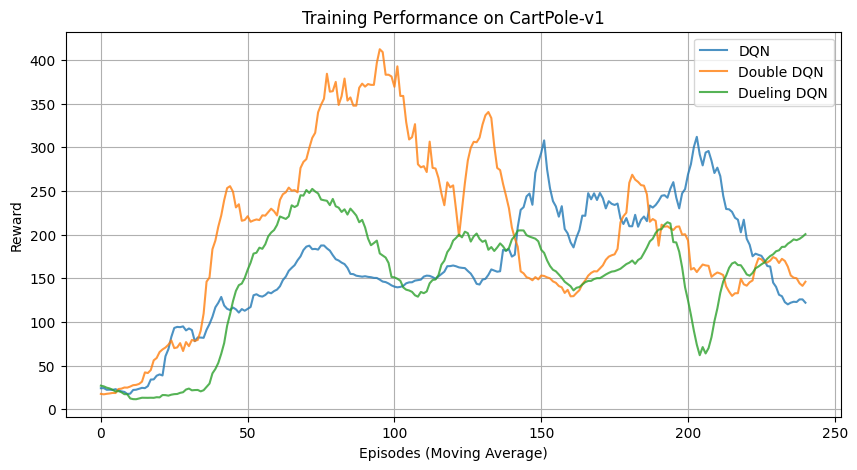

In [4]:
import gym 
import math 
import random 
import numpy as np 
# 兼容性修复：由于新版 NumPy 移除了 bool8，而旧版 gym 仍有引用，这里为其添加一个别名映射以防止报错 
np.bool8 = np.bool_ 
import matplotlib.pyplot as plt 
import torch 
import torch.nn as nn 
import torch.nn.functional as F 
import torch.optim as optim 
from collections import deque 
 
# 1. 定义一个综合的 Q 网络类，支持切换 Standard DQN 和 Dueling DQN 结构 
class QNet(nn.Module): 
    def __init__(self, state_dim, action_dim, hidden_dim=128, use_dueling=False): 
        super(QNet, self).__init__() 
        # 标志位：是否使用 Dueling 架构 
        self.use_dueling = use_dueling 
         
        # 公共特征提取层 
        self.feature_layer = nn.Sequential( 
            nn.Linear(state_dim, hidden_dim), 
            nn.ReLU() 
        ) 
         
        if self.use_dueling: 
            # 如果使用 Dueling 架构，则拆分出价值流 (V) 和优势流 (A) 
            self.value_stream = nn.Sequential( 
                nn.Linear(hidden_dim, hidden_dim), 
                nn.ReLU(), 
                nn.Linear(hidden_dim, 1) 
            ) 
            self.advantage_stream = nn.Sequential( 
                nn.Linear(hidden_dim, hidden_dim), 
                nn.ReLU(), 
                nn.Linear(hidden_dim, action_dim) 
            ) 
        else: 
            # 否则，按照标准 DQN 直接输出动作维度对应的 Q 值 
            self.q_layer = nn.Sequential( 
                nn.Linear(hidden_dim, hidden_dim), 
                nn.ReLU(), 
                nn.Linear(hidden_dim, action_dim) 
            ) 
             
    def forward(self, x): 
        # 先提取特征 
        features = self.feature_layer(x) 
        if self.use_dueling: 
            # 分别计算 V 和 A，然后组合得出最终的 Q 
            V = self.value_stream(features) 
            A = self.advantage_stream(features) 
            Q = V + (A - A.mean(dim=1, keepdim=True)) 
        else: 
            # 标准方式直接计算输出 Q 
            Q = self.q_layer(features) 
        return Q 
 
# 2. 定义经验回放缓冲区 
class ReplayBuffer: 
    def __init__(self, capacity): 
        # 利用双端队列，限制最大容量 
        self.buffer = deque(maxlen=capacity) 
         
    def push(self, state, action, reward, next_state, done): 
        # 存入一条经验 
        self.buffer.append((state, action, reward, next_state, done)) 
         
    def sample(self, batch_size): 
        # 随机采样 batch_size 大小的经验批次 
        states, actions, rewards, next_states, dones = zip(*random.sample(self.buffer, batch_size)) 
        # 转换为 NumPy 数组格式返回 
        return np.array(states), actions, rewards, np.array(next_states), dones 
     
    def __len__(self): 
        # 返回当前缓冲区内的数据量 
        return len(self.buffer) 
 
# 3. 定义 DQN 智能体类，包含动作选择、参数更新和同步等核心逻辑 
class DQNAgent: 
    def __init__(self, state_dim, action_dim, use_double=False, use_dueling=False): 
        self.action_dim = action_dim 
        # 标志位：是否使用 Double DQN 算法 
        self.use_double = use_double 
         
        # 自动检测是否可用 GPU 
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
         
        # 初始化主网络和目标网络，并放到相应的设备（CPU/GPU）上 
        self.q_net = QNet(state_dim, action_dim, use_dueling=use_dueling).to(self.device) 
        self.target_net = QNet(state_dim, action_dim, use_dueling=use_dueling).to(self.device) 
        # 将目标网络参数初始化为主网络参数 
        self.target_net.load_state_dict(self.q_net.state_dict()) 
         
        # 定义 Adam 优化器用于主网络的参数更新，学习率设为 1e-3 
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=1e-3) 
        # 初始化经验回放缓冲区，容量设为 10000 
        self.buffer = ReplayBuffer(10000) 
         
        self.batch_size = 64      # 每次更新时采样的批次大小 
        self.gamma = 0.99         # 奖励折扣因子，用于计算未来的长远价值 
         
        # Epsilon-greedy 探索策略参数 
        self.epsilon_start = 1.0  # 初始探索率（100% 随机动作） 
        self.epsilon_final = 0.01 # 最终探索率（1% 随机动作） 
        self.epsilon_decay = 500  # 探索率衰减的速度参数 
        self.frame_idx = 0        # 记录当前智能体已经执行的总步数 
         
    def select_action(self, state): 
        # 根据指数衰减公式计算当前的 epsilon 值 
        epsilon = self.epsilon_final + (self.epsilon_start - self.epsilon_final) *                   math.exp(-1. * self.frame_idx / self.epsilon_decay) 
        self.frame_idx += 1 # 更新步数计数器 
         
        # 生成一个随机数，如果大于 epsilon，则执行贪心动作（利用模型） 
        if random.random() > epsilon: 
            # 将状态转换为 Tensor，并增加 batch 维度 (unsqueeze(0)) 
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device) 
            # 在不计算梯度的模式下使用主网络前向传播 
            with torch.no_grad(): 
                q_values = self.q_net(state_tensor) 
            # 选取 Q 值最大的动作索引（即 argmax），并转换回标量 
            action = q_values.max(1)[1].item() 
        else: 
            # 如果小于等于 epsilon，则随机选择一个动作进行探索 
            action = random.randrange(self.action_dim) 
        return action 
     
    def update(self): 
        # 只有当缓冲区里的数据量大于等于批量大小时，才进行网络更新 
        if len(self.buffer) < self.batch_size: 
            return 
         
        # 采样一个批次的数据 
        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size) 
         
        # 将采样出的数据统一转换为 PyTorch 的 Tensor，并放置到对应的设备上 
        states = torch.FloatTensor(states).to(self.device) 
        actions = torch.LongTensor(actions).to(self.device) 
        rewards = torch.FloatTensor(rewards).to(self.device) 
        next_states = torch.FloatTensor(next_states).to(self.device) 
        dones = torch.FloatTensor(dones).to(self.device) 
         
        # ========== 计算当前状态预测的 Q 值 ========== 
        # 将 states 输入主网络得到所有动作的 Q 值矩阵 
        q_values = self.q_net(states) 
        # 用 gather 方法提取我们真实采取的那个动作对应的 Q 值，并在最后压缩维度 
        q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze(1) 
         
        # ========== 计算目标 (Target) Q 值 ========== 
        # 目标 Q 值的计算过程中不参与梯度反向传播 
        with torch.no_grad(): 
            if self.use_double: 
                # Double DQN 的做法：解耦动作选择和动作评估 
                # 1. 使用当前主网络 q_net 来选择下一个状态下使 Q 最大的动作（防止目标网络带来的高估） 
                next_actions = self.q_net(next_states).max(1)[1] 
                # 2. 使用目标网络 target_net 来评估选出的动作的具体价值 
                next_q_values = self.target_net(next_states) 
                next_q_value = next_q_values.gather(1, next_actions.unsqueeze(1)).squeeze(1) 
            else: 
                # Standard DQN 的做法：直接使用目标网络 target_net 去评估下一个状态的最大动作价值 
                # max(1)[0] 表示取每一行的最大值 
                next_q_value = self.target_net(next_states).max(1)[0] 
             
            # 计算期望的 Q 值（目标值）：当前奖励 + 折扣未来价值（如果当前已结束，则 done 为 1，未来价值为 0） 
            expected_q_value = rewards + self.gamma * next_q_value * (1 - dones) 
         
        # 计算预测的 Q 值和目标期望 Q 值之间的均方误差 (MSE Loss) 
        loss = F.mse_loss(q_value, expected_q_value) 
         
        # 清空之前的梯度 
        self.optimizer.zero_grad() 
        # 反向传播计算梯度 
        loss.backward() 
        # 根据梯度更新网络参数 
        self.optimizer.step() 
         
    def sync_target(self): 
        # 辅助方法：将主网络的参数同步给目标网络 (硬更新) 
        self.target_net.load_state_dict(self.q_net.state_dict()) 
 
# 4. 定义训练智能体的总循环函数 
def train_agent(agent, env_name="CartPole-v1", max_episodes=200): 
    # 初始化 Gym 环境（此处使用了较通用写法以适配不同版本 Gym） 
    env = gym.make(env_name) 
    rewards = [] # 记录每一个 episode 的总奖励，用于后续绘图 
     
    for episode in range(max_episodes): 
        state = env.reset() 
        # 兼容 Gym 新老版本在 reset() 时返回格式不同的问题 (新版本返回 (state, info)) 
        if isinstance(state, tuple): 
            state = state[0] 
             
        episode_reward = 0  # 当前回合的累计奖励 
        done = False        # 标记是否到达终止状态 
        truncated = False   # 标记是否达到步数上限被截断 
         
        while not (done or truncated): 
            # 智能体根据当前状态选择动作 
            action = agent.select_action(state) 
             
            # 环境执行动作，返回执行结果 
            step_result = env.step(action) 
            # 兼容 Gym 新老版本 step() 返回参数数量不同的问题 
            if len(step_result) == 5: 
                # 新版本返回 5 个参数: observation, reward, terminated, truncated, info 
                next_state, reward, done, truncated, _ = step_result 
            else: 
                # 老版本返回 4 个参数: observation, reward, done, info 
                next_state, reward, done, _ = step_result 
                truncated = False 
             
            # 将交互收集到的这条经验保存到缓冲池中 
            agent.buffer.push(state, action, reward, next_state, done or truncated) 
            # 触发一次网络参数更新尝试 
            agent.update() 
             
            # 转移到下一个状态 
            state = next_state 
            episode_reward += reward 
             
        # 每个回合结束后，每隔 10 个 episode 执行一次目标网络参数同步 
        if episode % 10 == 0: 
            agent.sync_target() 
             
        rewards.append(episode_reward) 
        # 每隔 50 个回合打印一次当前的平均表现 
        if (episode + 1) % 50 == 0: 
            print(f"Episode {episode+1}/{max_episodes}, Reward: {np.mean(rewards[-20:]):.2f}") 
             
    # 训练结束后关闭环境释放资源 
    env.close() 
    return rewards 
 
# ================= 实验对比代码 ================= 
state_dim = 4      # CartPole 状态维度为 4 
action_dim = 2     # 只有向左和向右 2 个动作 
max_episodes = 250 # 每种算法训练 250 个回合 
 
# 进行 Standard DQN 的训练 
print("--- Training Standard DQN ---") 
dqn_agent = DQNAgent(state_dim, action_dim, use_double=False, use_dueling=False) 
dqn_rewards = train_agent(dqn_agent, max_episodes=max_episodes) 
 
# 进行 Double DQN 的训练，以观察解耦目标网络估计带来的效果提升 
print(" --- Training Double DQN ---") 
ddqn_agent = DQNAgent(state_dim, action_dim, use_double=True, use_dueling=False) 
ddqn_rewards = train_agent(ddqn_agent, max_episodes=max_episodes) 
 
# 进行 Dueling DQN 的训练，以观察状态价值和动作优势分离带来的效果提升 
print(" --- Training Dueling DQN ---") 
dueling_agent = DQNAgent(state_dim, action_dim, use_double=False, use_dueling=True) 
dueling_rewards = train_agent(dueling_agent, max_episodes=max_episodes) 
 
# ================= 绘制对比曲线 ================= 
def moving_average(a, n=10): 
    # 实现一个简单的滑动平均函数以平滑学习曲线，使趋势更明显 
    ret = np.cumsum(a, dtype=float) 
    ret[n:] = ret[n:] - ret[:-n] 
    return ret[n - 1:] / n 
 
plt.figure(figsize=(10, 5)) 
# 绘制三种算法的滑动平均收益曲线 
plt.plot(moving_average(dqn_rewards), label="DQN", alpha=0.8) 
plt.plot(moving_average(ddqn_rewards), label="Double DQN", alpha=0.8) 
plt.plot(moving_average(dueling_rewards), label="Dueling DQN", alpha=0.8) 
plt.title("Training Performance on CartPole-v1") 
plt.xlabel("Episodes (Moving Average)") 
plt.ylabel("Reward") 
plt.legend() 
plt.grid(True) 
plt.show()

#### 本章小结

本章我们深入探讨了深度强化学习的奠基算法 DQN（Deep Q-Network）。它优雅地融合了 Q-Learning 与深度神经网络，并针对性地解决了两者结合带来的不稳定问题。

**关键概念回顾**：
- 深度 Q 网络（DQN）：使用神经网络近似 $Q(s, a)$。
- 经验回放（Experience Replay）：打破时序相关性，重复利用样本。
- 目标网络（Target Network）：提供稳定的更新目标标签。
- Double DQN：解耦选择动作和评估动作，防止 Q 值高估。
- Dueling DQN：将 Q 值的预估拆解为状态价值 V 和优势函数 A。
- $\epsilon$-greedy 衰减与软更新（Soft Update）。

**下一章预告**：
基于价值的方法（Value-based Methods）如 DQN 通常只适用于离散动作空间。如果动作是连续的（例如机器人的关节角度），找到 $\max_a Q(s, a)$ 会变得非常困难。下一章我们将学习**策略梯度方法（Policy Gradient Methods）**，直接优化策略本身，为连续控制打下基础。
